# Oil Sands Distance Analysis (6 Lakes)

This notebook analyzes how water chemistry varies with distance from oil sands operations.

Lakes:
- Near: Isadore, Mildred
- Mid: Kearl, McClelland
- Far: Namur, Gregoire

Methods:
- PCA (visual clustering)
- ANOVA (statistical differences)
- Random Forest (key drivers)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from scipy.stats import f_oneway





## Load/Label Data

In [12]:
isadore = pd.read_csv('/Users/muntahaaltaie/Desktop/far/isadore_cleaned.csv')
mildred = pd.read_csv('/Users/muntahaaltaie/Desktop/far/mildred_cleaned.csv')
kearl = pd.read_csv('/Users/muntahaaltaie/Desktop/far/kearl_cleaned.csv')
mcclelland = pd.read_csv('/Users/muntahaaltaie/Desktop/far/mcclelland_lake_cleaned.csv')
namur = pd.read_csv('/Users/muntahaaltaie/Desktop/far/namur_cleaned.csv')
gregoire = pd.read_csv('/Users/muntahaaltaie/Desktop/far/gregoire_cleaned.csv')

# Assign labels
isadore['lake'] = 'Isadore'
mildred['lake'] = 'Mildred'
kearl['lake'] = 'Kearl'
mcclelland['lake'] = 'McClelland'
namur['lake'] = 'Namur'
gregoire['lake'] = 'Gregoire'

isadore['distance_group'] = 'Near'
mildred['distance_group'] = 'Near'

kearl['distance_group'] = 'Mid'
mcclelland['distance_group'] = 'Mid'

namur['distance_group'] = 'Far'
gregoire['distance_group'] = 'Far'

df = pd.concat([isadore, mildred, kearl, mcclelland, namur, gregoire], ignore_index=True)
df.head()

,lake,sampling_timestamp,sample_timestamp,site_name,station_name,depth,value_sign,unit_symbol,method,laboratory,...,Phosphorus Total,Vanadium Dissolved,Turbidity,pH,Oxygen dissolved % saturation,OXYGEN BIOCHEMICAL DEMAND,calcium_total_recoverable,nitrogen_dissolved_no3_no2,nitrogen_particulate_total,oxygen_dissolved_winkler
0,Isadore,2004-07-30 12:00:00,2004-07-30 11:00:00,ISADORE'S LAKE,COMPOSITE,NaN,'---,µg/l,1849.0,Alberta Research Council,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Isadore,2005-08-01 12:00:00,2005-08-01 11:00:00,ISADORE'S LAKE,COMPOSITE,NaN,'---,µg/l,1849.0,Alberta Research Council,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Isadore,2006-07-24 12:00:00,2006-07-24 11:00:00,ISADORE'S LAKE,COMPOSITE,NaN,<,µg/l,1849.0,Alberta Research Council,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Isadore,2007-07-20 12:00:00,2007-07-20 11:00:00,ISADORE'S LAKE,COMPOSITE,NaN,<,µg/l,1849.0,Alberta Research Council,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Isadore,2008-07-14 12:00:00,2008-07-14 11:00:00,ISADORE'S LAKE,COMPOSITE,NaN,<,µg/l,1849.0,Alberta Research Council,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Clean Numeric Parameters

In [13]:
df_numeric = df.copy()

# Convert to numeric
df_numeric = df_numeric.apply(pd.to_numeric, errors='coerce')

# Remove bad columns
bad_cols = ['rdl','sampling_number','sample_number','method','laboratory',
            'latitude_decimal_degrees','longitude_decimal_degrees']
df_numeric = df_numeric.drop(columns=[c for c in bad_cols if c in df_numeric.columns], errors='ignore')

# Drop empty + low variance
df_numeric = df_numeric.dropna(axis=1, how='all')
df_numeric = df_numeric.loc[:, df_numeric.nunique() > 1]

# Fill missing
df_numeric = df_numeric.fillna(df_numeric.median())

print(df_numeric.columns)
df_numeric.head()

Index(['depth', 'aluminum_dissolved', 'aluminum_total_recoverable',
       'calcium_dissolved', 'calcium_total', 'copper_dissolved',
       'copper_total_recoverable', 'lead_dissolved', 'lead_total_recoverable',
       'nickel_dissolved', 'nickel_total_recoverable',
       'oxygen_biochemical_demand', 'oxygen_dissolved_percent_saturation',
       'ph', 'phosphorus_total', 'phosphorus_total_dissolved', 'turbidity',
       'vanadium_dissolved', 'vanadium_total_recoverable', 'collection_code',
       'calcium_dissolved_filtered', 'copper_total', 'lead_extractable',
       'lead_total', 'nickel_total', 'nitrogen_dissolved_nitrate',
       'nitrogen_dissolved_nitrite', 'oxygen_dissolved_field_meter',
       'oxygen_total_cod', 'ph_lab', 'turbidity_jtu', 'turbidity_ntu',
       'nitrogen_dissolved', 'Value', 'RDL', 'Method', 'Aluminum Dissolved',
       'Aluminum Total Recoverable', 'Calcium Dissolved', 'Calcium Total',
       'Copper Dissolved', 'Copper Total Recoverable', 'Lead Dissolved',

,depth,aluminum_dissolved,aluminum_total_recoverable,calcium_dissolved,calcium_total,copper_dissolved,copper_total_recoverable,lead_dissolved,lead_total_recoverable,nickel_dissolved,...,Nitrogen Dissolved,Phosphorus Total Dissolved,Phosphorus Total,Vanadium Dissolved,Turbidity,pH,Oxygen dissolved % saturation,calcium_total_recoverable,nitrogen_dissolved_no3_no2,oxygen_dissolved_winkler
0,0.1,1.34,13.0,21.05,23.0,0.19,0.2545,0.02,0.03895,0.06,...,298.5,7.1,0.015,0.049,0.65,7.43,92.4,19.25,0.0745,9.44
1,0.1,1.98,13.0,21.05,23.0,0.19,0.2545,0.02,0.03895,0.06,...,298.5,7.1,0.015,0.049,0.65,7.43,92.4,19.25,0.0745,9.44
2,0.1,0.50,13.0,21.05,23.0,0.19,0.2545,0.02,0.03895,0.06,...,298.5,7.1,0.015,0.049,0.65,7.43,92.4,19.25,0.0745,9.44
3,0.1,0.50,13.0,21.05,23.0,0.19,0.2545,0.02,0.03895,0.06,...,298.5,7.1,0.015,0.049,0.65,7.43,92.4,19.25,0.0745,9.44
4,0.1,0.50,13.0,21.05,23.0,0.19,0.2545,0.02,0.03895,0.06,...,298.5,7.1,0.015,0.049,0.65,7.43,92.4,19.25,0.0745,9.44


## Normalization 

In [ ]:
# Normalize names
def normalize(col):
    col = str(col).strip().lower()
    col = col.replace('%', 'percent')
    col = re.sub(r'[^\w]+', '_', col)
    col = re.sub(r'_+', '_', col)
    return col.strip('_')

df.columns = [normalize(c) for c in df.columns]

# Standerdize variables
def normalize(col):
rename_map = {
    'ph_lab': 'ph',
    'ph_units': 'ph',

    'turbidity_jtu': 'turbidity',
    'turbidity_ntu': 'turbidity',

    'nitrogen_dissolved_no3_no2': 'nitrogen_dissolved',
    'nitrogen_dissolved_nitrate': 'nitrogen_dissolved',
    'nitrogen_dissolved_nitrite': 'nitrogen_dissolved',
}

df = df.rename(columns=lambda c: rename_map.get(c, c))

# Merge duplicates
def normalize(col):
def merge_duplicates(df):
    merged = pd.DataFrame(index=df.index)

    for col in pd.unique(df.columns):
        same_cols = df.loc[:, df.columns == col]

        if same_cols.shape[1] == 1:
            merged[col] = same_cols.iloc[:, 0]
        else:
            merged[col] = same_cols.bfill(axis=1).iloc[:, 0]

    return merged

df = merge_duplicates(df)

# Drop non-analytical columns
def normalize(col):
drop_cols = ['collection_code', 'value', 'rdl', 'method']
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

# Keeps target seprate
def normalize(col):
y = df['distance_group'].copy()

# Builds numeric set 
def normalize(col):
analysis_vars = [
    'depth',
    'aluminum_dissolved',
    'aluminum_total_recoverable',
    'calcium_dissolved',
    'calcium_total',
    'copper_dissolved',
    'copper_total_recoverable',
    'lead_dissolved',
    'lead_total_recoverable',
    'nickel_dissolved',
    'nickel_total_recoverable',
    'oxygen_biochemical_demand',
    'oxygen_dissolved_percent_saturation',
    'ph',
    'phosphorus_total',
    'phosphorus_total_dissolved',
    'turbidity',
    'vanadium_dissolved',
    'vanadium_total_recoverable',
    'calcium_dissolved_filtered',
    'copper_total',
    'lead_extractable',
    'lead_total',
    'nickel_total',
    'nitrogen_dissolved',
    'oxygen_dissolved_field_meter',
    'oxygen_total_cod',
    'oxygen_dissolved_winkler'
]

available_vars = [c for c in analysis_vars if c in df.columns]

df_numeric = df[available_vars].copy()
df_numeric = df_numeric.apply(pd.to_numeric, errors='coerce')

# Remove fully empty and constant columns
df_numeric = df_numeric.dropna(axis=1, how='all')
df_numeric = df_numeric.loc[:, df_numeric.nunique() > 1]

# Fill numeric missing values only
df_numeric = df_numeric.fillna(df_numeric.median(numeric_only=True))

print("Final columns used:")
print(df_numeric.columns.tolist())

print("Shape:", df_numeric.shape)
df_numeric.head()

Final columns used:
['depth', 'aluminum_dissolved', 'aluminum_total_recoverable', 'calcium_dissolved', 'calcium_total', 'copper_dissolved', 'copper_total_recoverable', 'lead_dissolved', 'lead_total_recoverable', 'nickel_dissolved', 'nickel_total_recoverable', 'oxygen_biochemical_demand', 'oxygen_dissolved_percent_saturation', 'ph', 'phosphorus_total', 'phosphorus_total_dissolved', 'turbidity', 'vanadium_dissolved', 'vanadium_total_recoverable', 'calcium_dissolved_filtered', 'copper_total', 'lead_extractable', 'lead_total', 'nickel_total', 'nitrogen_dissolved', 'oxygen_dissolved_field_meter', 'oxygen_total_cod', 'oxygen_dissolved_winkler']
Shape: (1483, 28)


,depth,aluminum_dissolved,aluminum_total_recoverable,calcium_dissolved,calcium_total,copper_dissolved,copper_total_recoverable,lead_dissolved,lead_total_recoverable,nickel_dissolved,...,vanadium_total_recoverable,calcium_dissolved_filtered,copper_total,lead_extractable,lead_total,nickel_total,nitrogen_dissolved,oxygen_dissolved_field_meter,oxygen_total_cod,oxygen_dissolved_winkler
0,0.1,1.34,11.15,24.68,39.0,0.262,0.309,0.012,0.02955,0.178,...,0.227,21.0,0.003,0.00175,0.002,0.003,0.942,8.89,33.0,9.44
1,0.1,1.98,11.15,24.68,39.0,0.262,0.309,0.012,0.02955,0.178,...,0.227,21.0,0.003,0.00175,0.002,0.003,0.942,8.89,33.0,9.44
2,0.1,0.50,11.15,24.68,39.0,0.262,0.309,0.012,0.02955,0.178,...,0.227,21.0,0.003,0.00175,0.002,0.003,0.942,8.89,33.0,9.44
3,0.1,0.50,11.15,24.68,39.0,0.262,0.309,0.012,0.02955,0.178,...,0.227,21.0,0.003,0.00175,0.002,0.003,0.942,8.89,33.0,9.44
4,0.1,0.50,11.15,24.68,39.0,0.262,0.309,0.012,0.02955,0.178,...,0.227,21.0,0.003,0.00175,0.002,0.003,0.942,8.89,33.0,9.44


## PCA

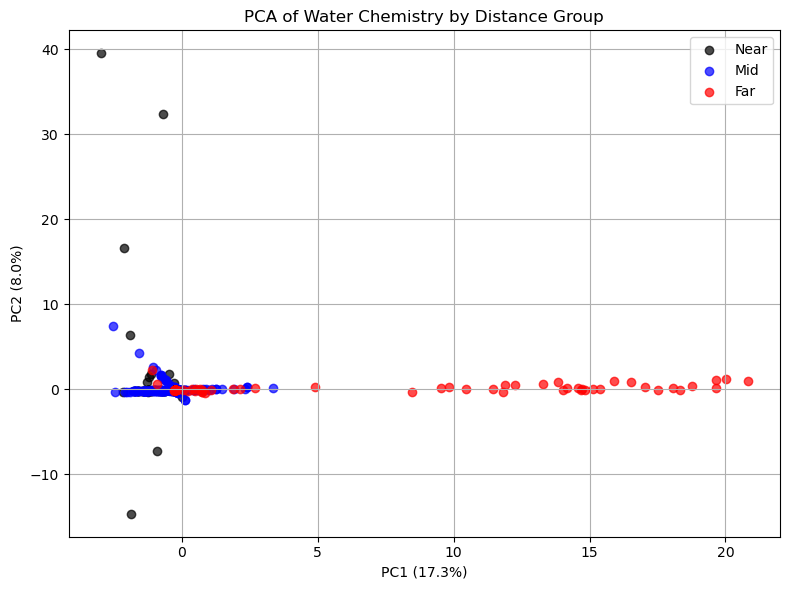

In [ ]:
X = df_numeric.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['distance_group'] = y.values

plt.figure(figsize=(8, 6))

colors = {
    'Near': 'black',
    'Mid': 'blue',
    'Far': 'red'
}

for group in ['Near', 'Mid', 'Far']:
    subset = pca_df[pca_df['distance_group'] == group]
    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        label=group,
        alpha=0.7,
        c=colors[group]
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
plt.title("PCA of Water Chemistry by Distance Group")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## ANOVA

In [ ]:
anova_results = {}

for col in df_numeric.columns:
    near = df_numeric[y == 'Near'][col].dropna()
    mid = df_numeric[y == 'Mid'][col].dropna()
    far = df_numeric[y == 'Far'][col].dropna()

    if len(near) > 1 and len(mid) > 1 and len(far) > 1:
        stat, p = f_oneway(near, mid, far)
        anova_results[col] = {
            'F_statistic': stat,
            'p_value': p
        }

anova_df = pd.DataFrame(anova_results).T.sort_values('p_value')
print(anova_df)

                                     F_statistic       p_value
calcium_dissolved                      32.197207  2.053927e-14
nickel_total_recoverable               31.031072  6.284653e-14
nickel_dissolved                       28.565208  6.725727e-13
ph                                     27.751954  1.472259e-12
calcium_total                          25.469778  1.332652e-11
phosphorus_total_dissolved             22.035643  3.713312e-10
calcium_dissolved_filtered             19.754216  3.414796e-09
nitrogen_dissolved                     19.049343  6.786820e-09
vanadium_dissolved                     13.921443  1.023674e-06
vanadium_total_recoverable             10.355039  3.420096e-05
phosphorus_total                        7.689337  4.762054e-04
depth                                   5.495321  4.190157e-03
turbidity                               4.265881  1.421252e-02
lead_total                              2.486019  8.358825e-02
copper_total                            2.033291  1.312

## Boxplots for significant ANOVA variables

Significant variables:
['calcium_dissolved', 'nickel_total_recoverable', 'nickel_dissolved', 'ph', 'calcium_total', 'phosphorus_total_dissolved', 'calcium_dissolved_filtered', 'nitrogen_dissolved', 'vanadium_dissolved', 'vanadium_total_recoverable', 'phosphorus_total', 'depth', 'turbidity']


<Figure size 600x400 with 0 Axes>

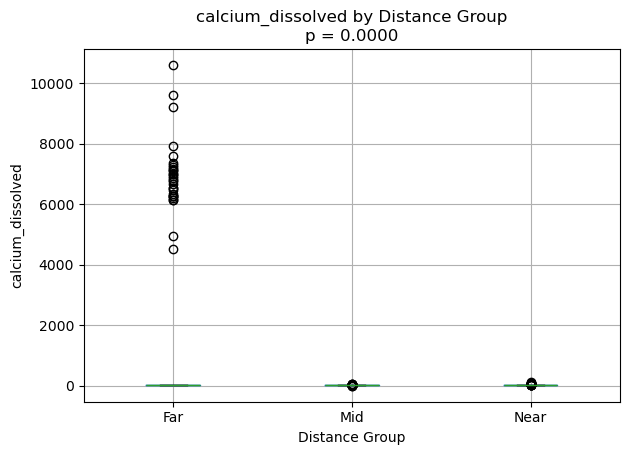

<Figure size 600x400 with 0 Axes>

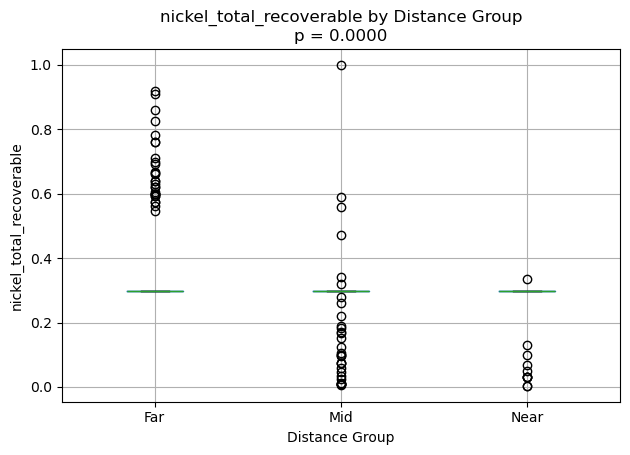

<Figure size 600x400 with 0 Axes>

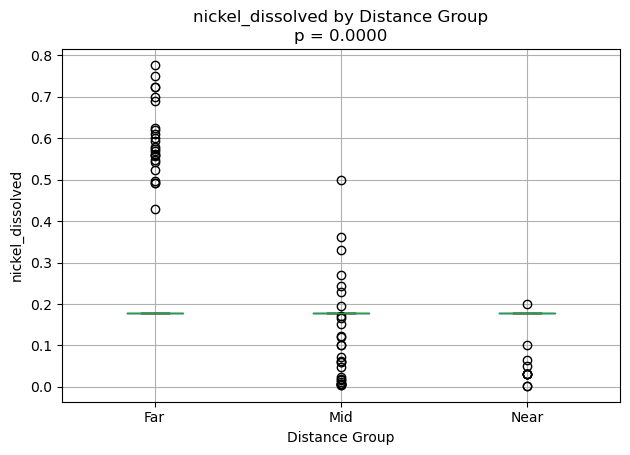

<Figure size 600x400 with 0 Axes>

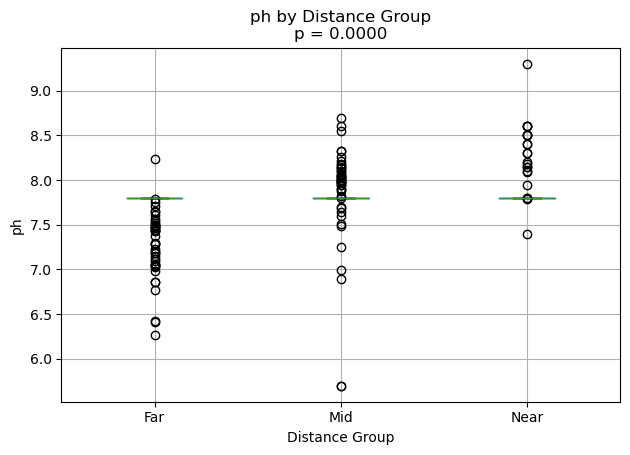

<Figure size 600x400 with 0 Axes>

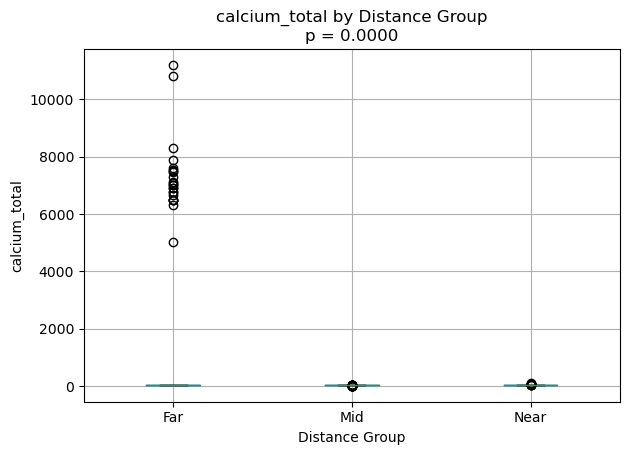

<Figure size 600x400 with 0 Axes>

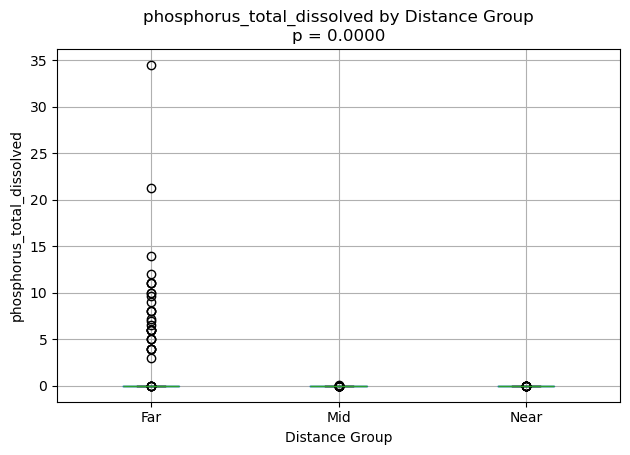

<Figure size 600x400 with 0 Axes>

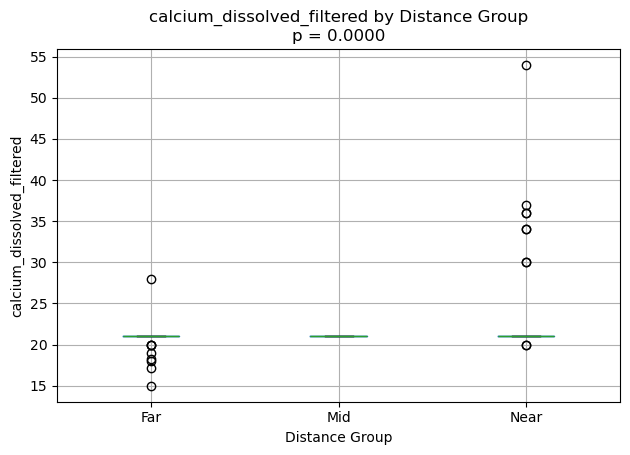

<Figure size 600x400 with 0 Axes>

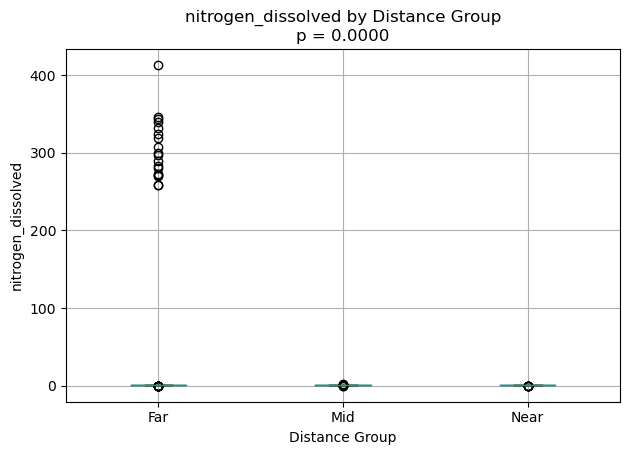

<Figure size 600x400 with 0 Axes>

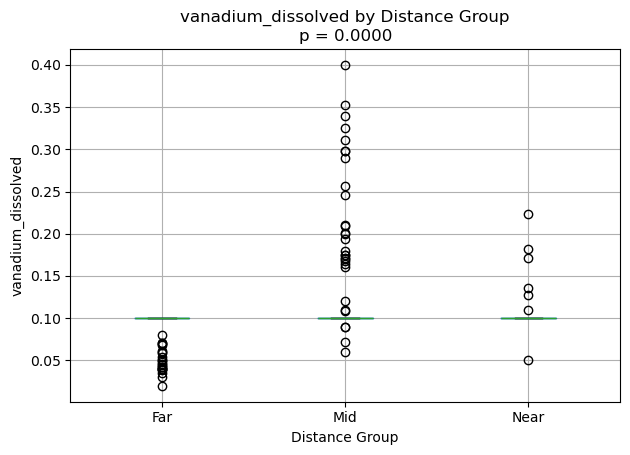

<Figure size 600x400 with 0 Axes>

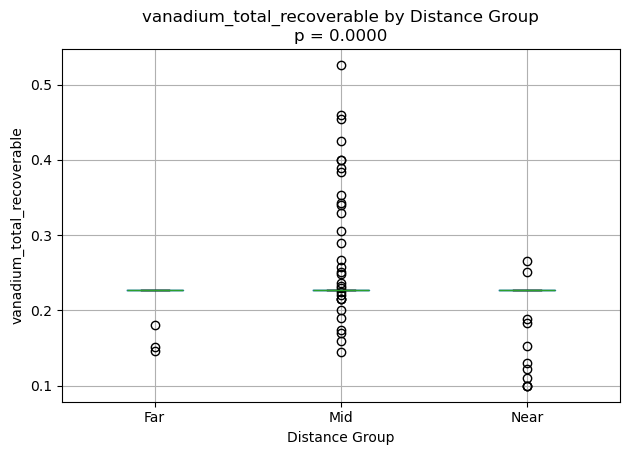

<Figure size 600x400 with 0 Axes>

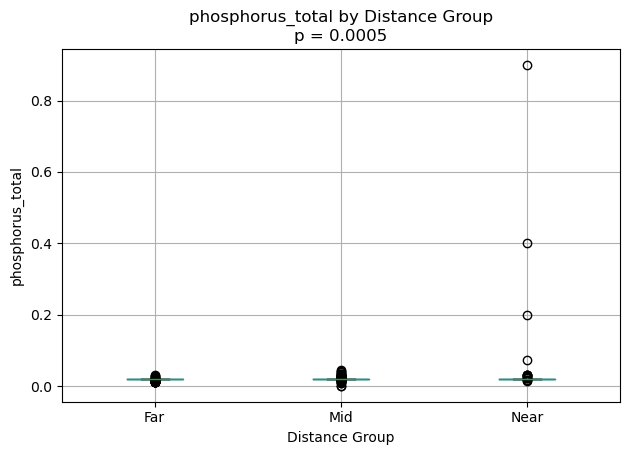

<Figure size 600x400 with 0 Axes>

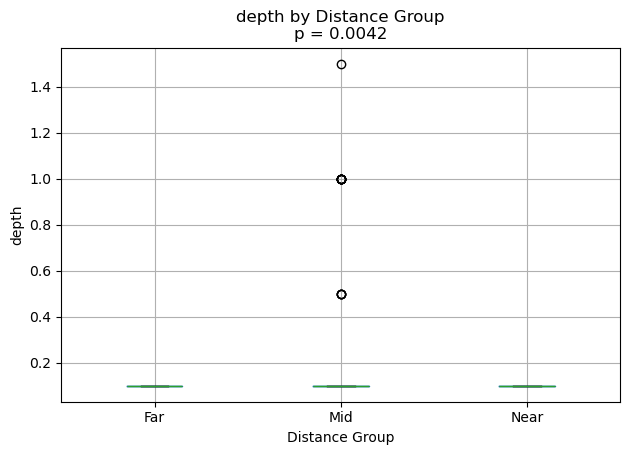

<Figure size 600x400 with 0 Axes>

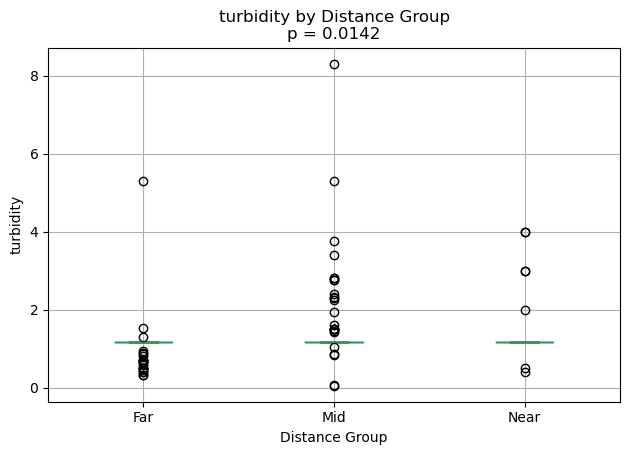

Significant variables:
['calcium_dissolved', 'nickel_total_recoverable', 'nickel_dissolved', 'ph', 'calcium_total', 'phosphorus_total_dissolved', 'calcium_dissolved_filtered', 'nitrogen_dissolved', 'vanadium_dissolved', 'vanadium_total_recoverable', 'phosphorus_total', 'depth', 'turbidity']


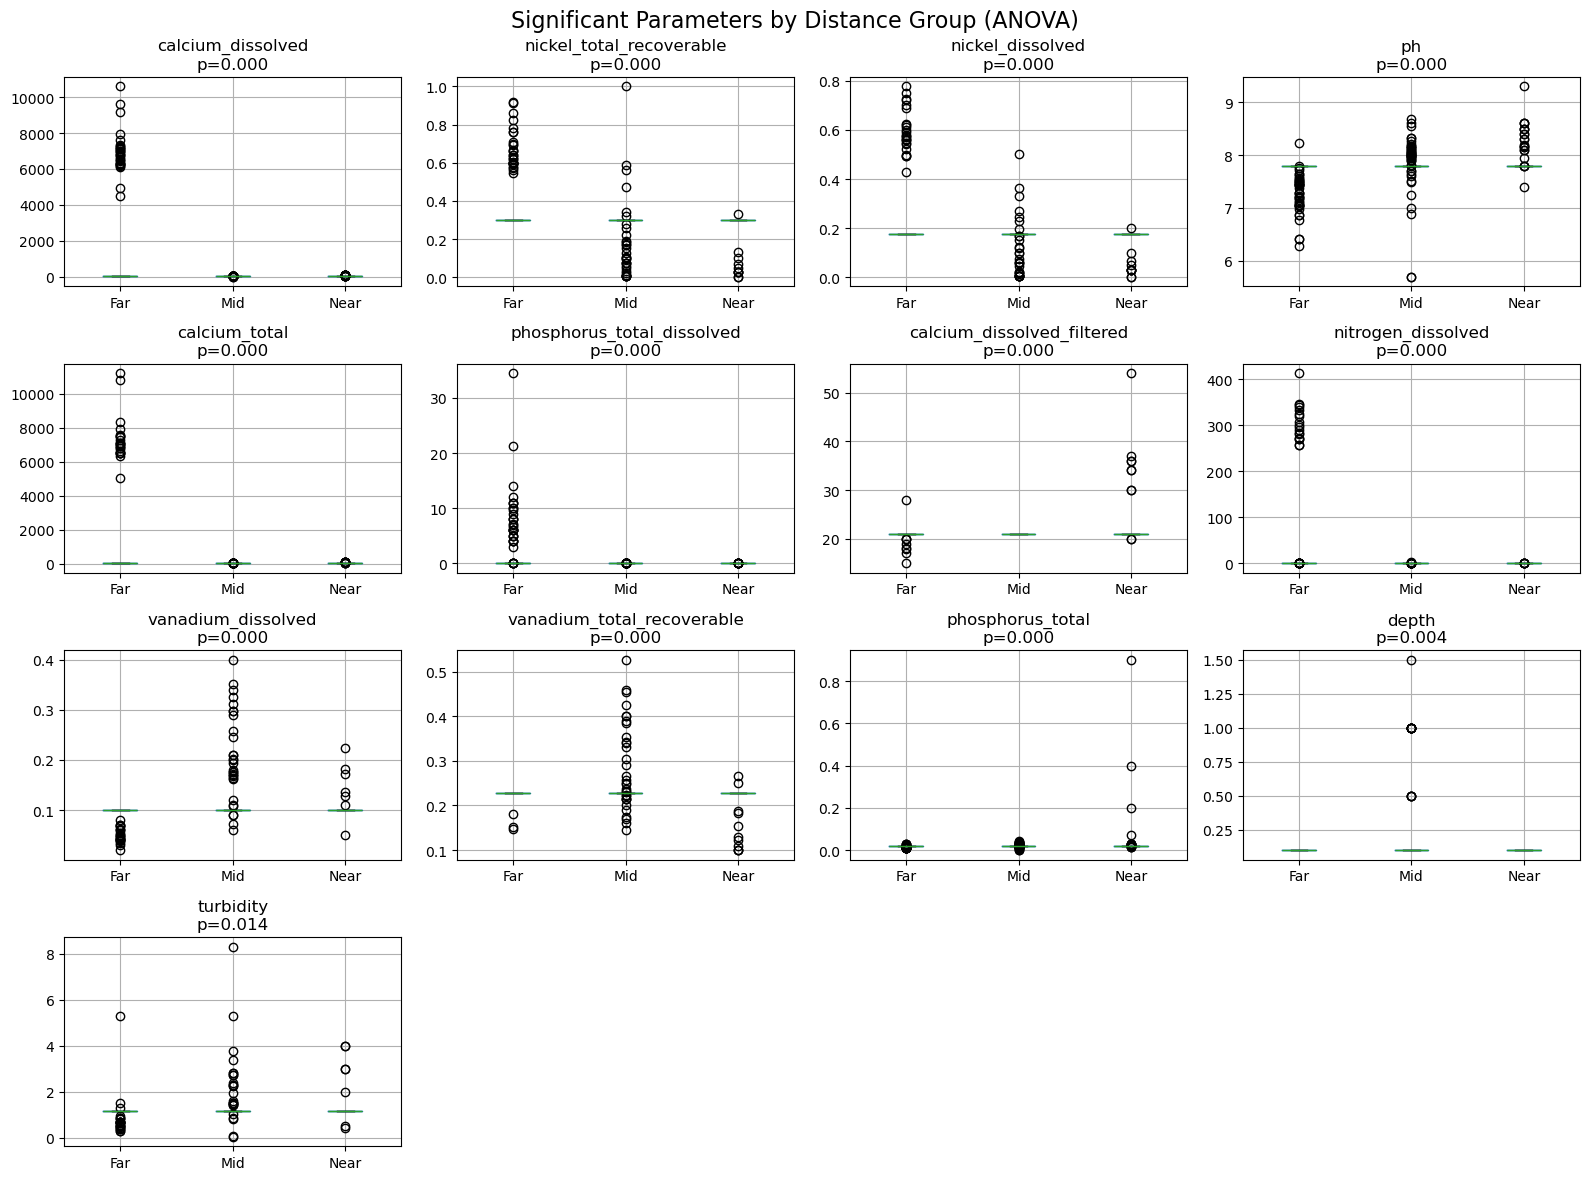

In [56]:
significant_vars = anova_df[anova_df['p_value'] < 0.05].index.tolist()

print("Significant variables:")
print(significant_vars)

for col in significant_vars:
    plot_df = pd.DataFrame({
        'distance_group': y,
        col: df_numeric[col]
    })

    plt.figure(figsize=(6, 4))
    plot_df.boxplot(column=col, by='distance_group')
    plt.title(f"{col} by Distance Group\np = {anova_df.loc[col, 'p_value']:.4f}")
    plt.suptitle("")
    plt.xlabel("Distance Group")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()
    
    import matplotlib.pyplot as plt
import numpy as np

# Get significant variables
significant_vars = anova_df[anova_df['p_value'] < 0.05].index.tolist()

print("Significant variables:")
print(significant_vars)

# Grid setup
n_cols = 4
n_rows = 4
max_plots = n_cols * n_rows

vars_to_plot = significant_vars[:max_plots]  # limit to 16

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(vars_to_plot):
    ax = axes[i]

    plot_df = pd.DataFrame({
        'distance_group': y,
        col: df_numeric[col]
    })

    plot_df.boxplot(column=col, by='distance_group', ax=ax)

    ax.set_title(f"{col}\np={anova_df.loc[col, 'p_value']:.3f}")
    ax.set_xlabel("")
    ax.set_ylabel("")

# Remove unused subplots
for j in range(len(vars_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Significant Parameters by Distance Group (ANOVA)", fontsize=16)
plt.tight_layout()
plt.show()

## Random Forest

In [ ]:
X = df_numeric.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8417508417508418

Classification Report:
              precision    recall  f1-score   support

         Far       0.97      0.94      0.95        96
         Mid       0.87      0.86      0.86       159
        Near       0.50      0.55      0.52        42

    accuracy                           0.84       297
   macro avg       0.78      0.78      0.78       297
weighted avg       0.85      0.84      0.84       297



## Confusion Matrix

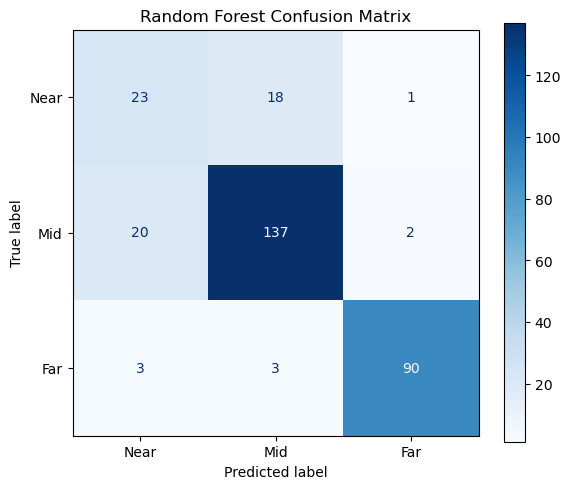

In [58]:
cm = confusion_matrix(y_test, y_pred, labels=['Near', 'Mid', 'Far'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Near', 'Mid', 'Far'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

## Feature Importance

In [59]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df)

                                feature  importance
25         oxygen_dissolved_field_meter    0.433683
2            aluminum_total_recoverable    0.069116
3                     calcium_dissolved    0.062441
13                                   ph    0.042716
4                         calcium_total    0.035491
9                      nickel_dissolved    0.033467
6              copper_total_recoverable    0.032730
14                     phosphorus_total    0.031552
15           phosphorus_total_dissolved    0.031532
8                lead_total_recoverable    0.030755
5                      copper_dissolved    0.030340
18           vanadium_total_recoverable    0.028247
10             nickel_total_recoverable    0.025177
7                        lead_dissolved    0.023217
1                    aluminum_dissolved    0.022319
17                   vanadium_dissolved    0.020586
11            oxygen_biochemical_demand    0.011622
16                            turbidity    0.007645
12  oxygen_d

## Feature Importance Plot

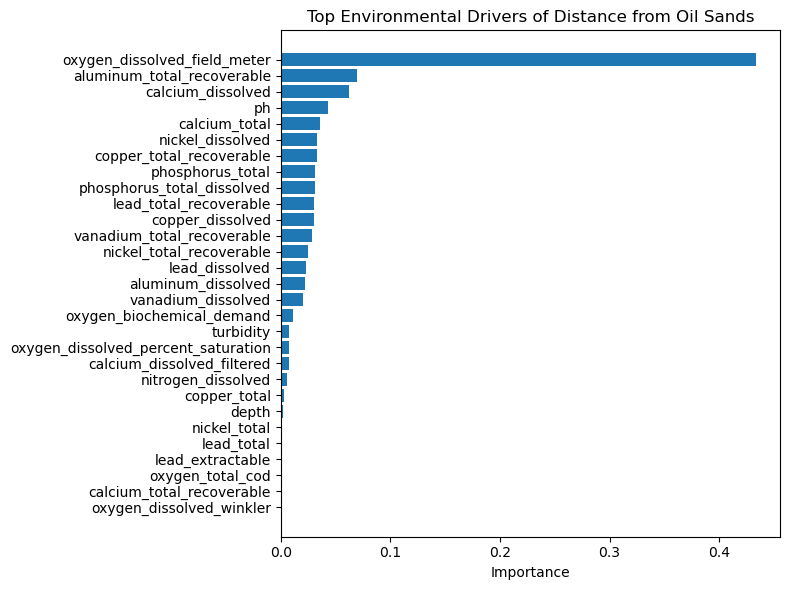

In [60]:
plt.figure(figsize=(8, 6))
plt.barh(
    importance_df['feature'][::-1],
    importance_df['importance'][::-1]
)
plt.xlabel("Importance")
plt.title("Top Environmental Drivers of Distance from Oil Sands")
plt.tight_layout()
plt.show()

In [61]:
anova_df.to_csv("anova_results.csv")
importance_df.to_csv("random_forest_feature_importance.csv", index=False)
pca_df.to_csv("pca_scores.csv", index=False)

print("Saved:")
print("- anova_results.csv")
print("- random_forest_feature_importance.csv")
print("- pca_scores.csv")

Saved:
- anova_results.csv
- random_forest_feature_importance.csv
- pca_scores.csv
